In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import quantum_algorithms as qa
from quantum_algorithms import depolarizing as dep
import quantum_algorithms.deutsch_jozsa as dj

In [16]:
# Experiment sets

shots = 1024
n_values = [1, 3, 5]
p_values = np.arange(0, 1.01, 0.05)

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced_parity": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "D(P)1_before_H": qa.depolarizing.deutsch_jozsa_depolarizing1,
    "D(P)2_after_first_H": qa.depolarizing.deutsch_jozsa_depolarizing2,
    "D(P)3_after_oracle": qa.depolarizing.deutsch_jozsa_depolarizing3,
    "D(P)4_after_final_H": qa.depolarizing.deutsch_jozsa_depolarizing4,
}


results = []

for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)

        probs_ref = qa.deutsch_jozsa.measure_probs_first_n(state_ref, n)
        probs_ref = qa.depolarizing.clean_probs(probs_ref)

        samples_ref = qa.deutsch_jozsa.sample_probs(probs_ref, shots)
        P0_ref = samples_ref[0] / shots

        for p in p_values:

            results.append({
                "n": n,
                "p": p,
                "target_qubit": target_qubit,
                "function": function_name,
                "error_position": "no_error",
                "P0": P0_ref,
                "shots": shots,
            })

            for error_name, error_function in error_positions.items():

                rho_error = error_function(n, f, p, target_qubit)

                probs_error = qa.depolarizing.measure_probs_first_n_rho(
                    rho_error,
                    n
                )

                probs_error = qa.depolarizing.clean_probs(probs_error)

                samples_error = qa.deutsch_jozsa.sample_probs(
                    probs_error,
                    shots
                )

                P0_error = samples_error[0] / shots

                results.append({
                    "n": n,
                    "p": p,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": error_name,
                    "P0": P0_error,
                    "shots": shots,
                })

df_dep = pd.DataFrame(results)

df_dep.head()

Running n = 1
Running n = 3
Running n = 5


,n,p,target_qubit,function,error_position,P0,shots
0,1,0.0,0,constant_1,no_error,1.0,1024
1,1,0.0,0,constant_1,D(P)1_before_H,1.0,1024
2,1,0.0,0,constant_1,D(P)2_after_first_H,1.0,1024
3,1,0.0,0,constant_1,D(P)3_after_oracle,1.0,1024
4,1,0.0,0,constant_1,D(P)4_after_final_H,1.0,1024


In [17]:
df_dep.to_csv("dja_depolarizing_results_shots_1024.csv", index=False)

In [20]:
def plot_depolarizing_positions(df, n_plot, function_plot):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["function"] == function_plot)
    ]

    plt.figure(figsize=(8, 5), dpi=150)

    labels = {
    "no_error": "Ideal circuit",
    "D(P)1_before_H": r"$D_p$ at $E_1$ (before H)",
    "D(P)2_after_first_H": r"$D_p$ at $E_2$ (after first H)",
    "D(P)3_after_oracle": r"$D_p$ at $E_3$ (after oracle)",
    "D(P)4_after_final_H": r"$D_p$ at $E_4$ (after final H)",
    }

    for error_pos, label in labels.items():
        subset = plot_df[plot_df["error_position"] == error_pos]

        plt.plot(
            subset["p"],
            subset["P0"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=label
        )

    plt.xlabel(r"Depolarizing probability $p$", fontsize=12)
    plt.ylabel(r"Probability $P(0\ldots0)$", fontsize=12)
    plt.title(
    rf"Effect of depolarizing noise on the Deutsch--Jozsa algorithm"
    "\n"
    rf"$\mathrm{{function}}={function_plot}$",
    fontsize=13)
    
    plt.ylim()
    plt.xlim()

    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show() 




In [21]:
def plot_depolarizing_sensitivity(df, n_plot, function_plot):

    df2 = df.copy()

    ideal = df2[df2["error_position"] == "no_error"][
        ["n", "function", "p", "P0"]
    ].rename(columns={"P0": "P0_ideal"})

    df2 = df2.merge(
        ideal,
        on=["n", "function", "p"],
        how="left"
    )

    plot_df = df2[
        (df2["n"] == n_plot) &
        (df2["function"] == function_plot) &
        (df2["error_position"] != "no_error")
    ].copy()

    plot_df["sensitivity"] = abs(plot_df["P0"] - plot_df["P0_ideal"])

    labels = {
        "D(P)1_before_H": r"$D_p$ at $E_1$",
        "D(P)2_after_first_H": r"$D_p$ at $E_2$",
        "D(P)3_after_oracle": r"$D_p$ at $E_3$",
        "D(P)4_after_final_H": r"$D_p$ at $E_4$",
    }

    plt.figure(figsize=(8, 5), dpi=150)

    for error_pos, label in labels.items():
        subset = plot_df[plot_df["error_position"] == error_pos]

        if subset.empty:
            continue

        plt.plot(
            subset["p"],
            subset["sensitivity"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=label
        )

    plt.xlabel(r"Depolarizing probability $p$", fontsize=12)
    plt.ylabel(r"Sensitivity $|P_{\mathrm{error}}-P_{\mathrm{ideal}}|$", fontsize=12)
    plt.title(
        rf"Sensitivity to depolarizing noise"
        "\n"
        rf"$f(x)=\mathrm{{{function_plot}}},\; n={n_plot}$",
        fontsize=13
    )

    plt.xlim(0, 1)
    plt.ylim(-0.05, 1.05)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

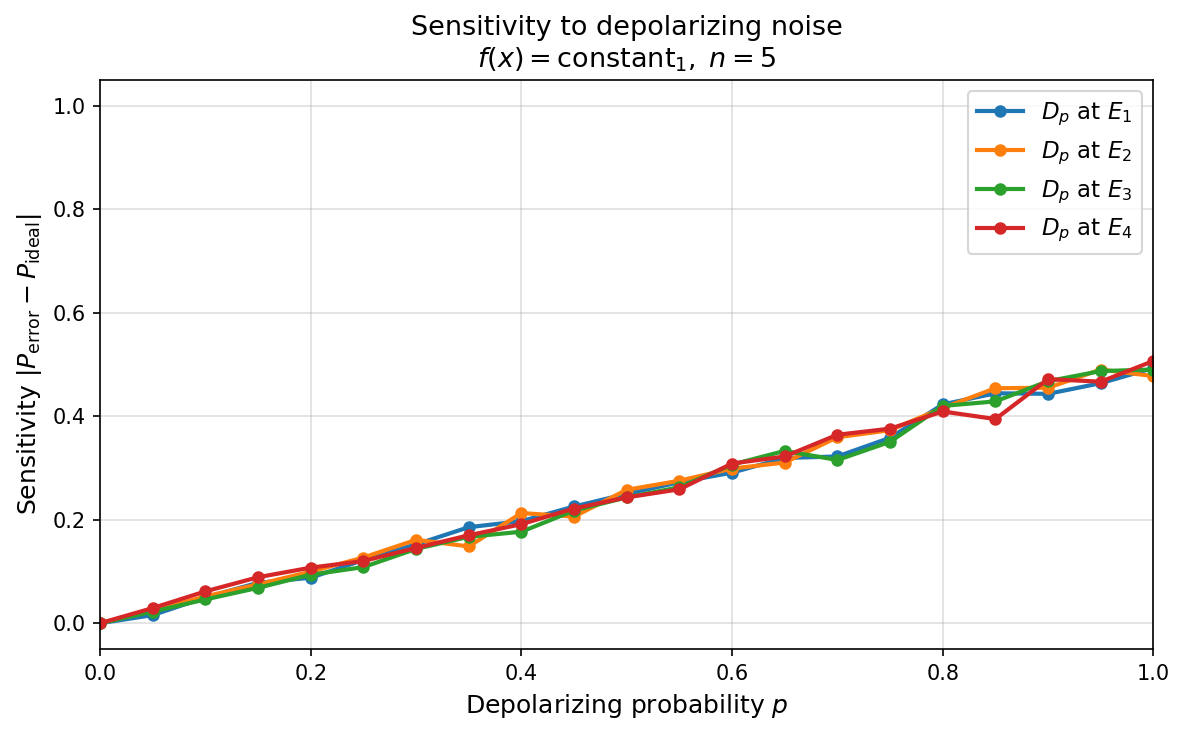

In [23]:
plot_depolarizing_sensitivity(df_dep, n_plot=5, function_plot="constant_1")

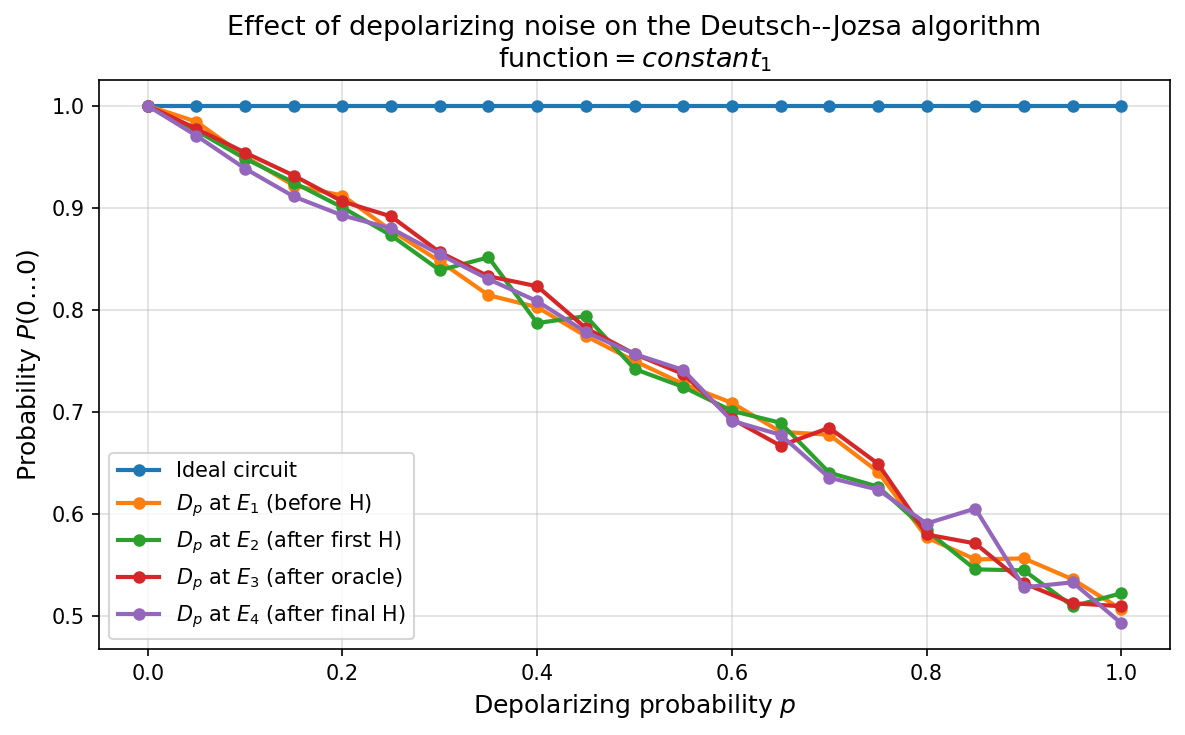

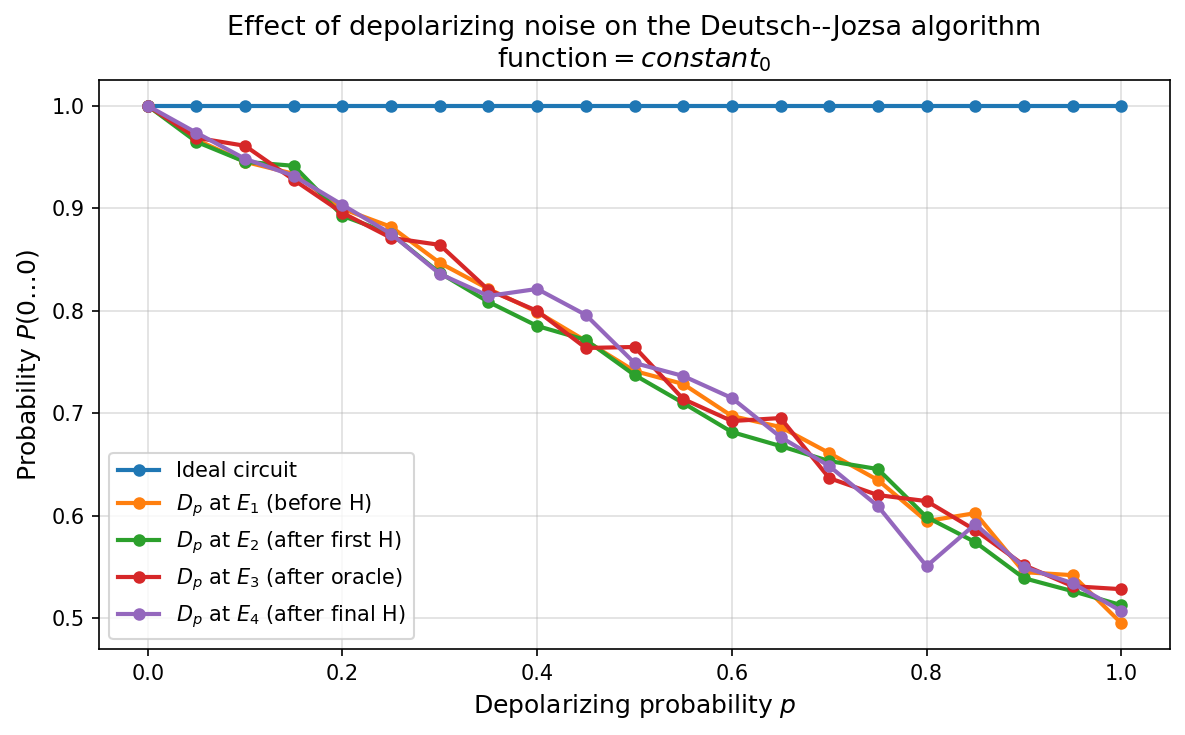

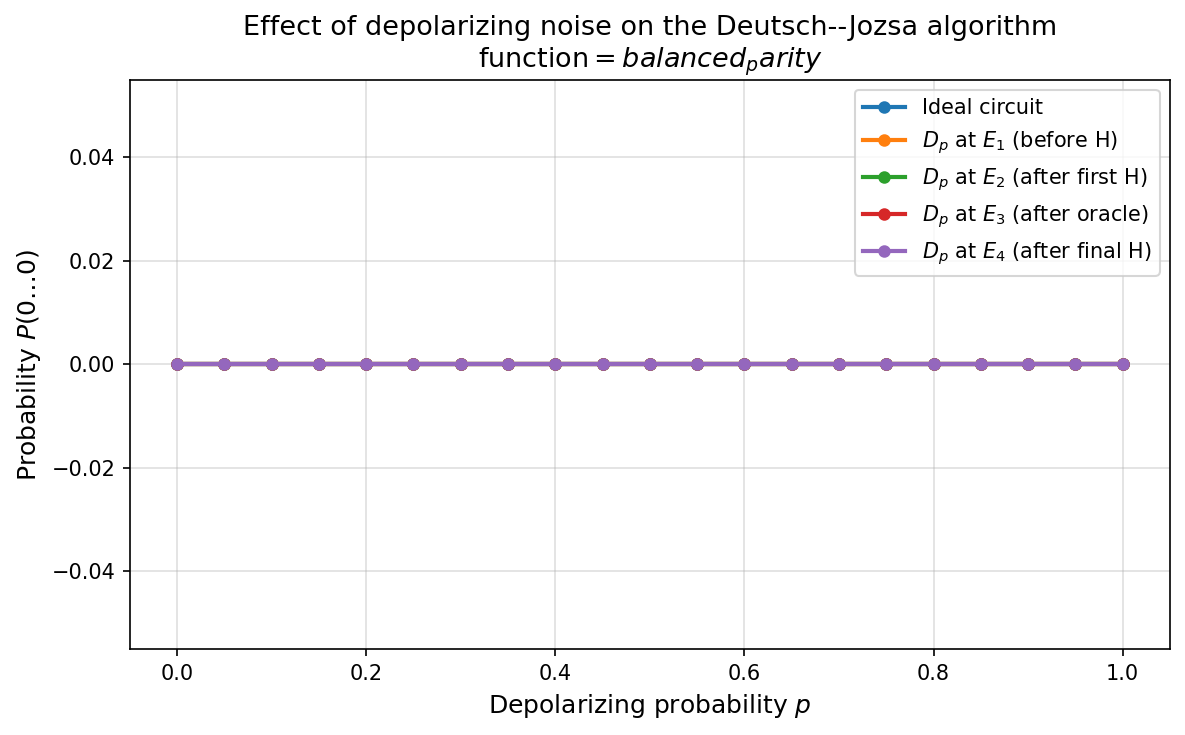

In [19]:
plot_depolarizing_positions(df_dep, n_plot=5, function_plot="constant_1")
plot_depolarizing_positions(df_dep, n_plot=5, function_plot="constant_0")
plot_depolarizing_positions(df_dep, n_plot=5, function_plot="balanced_parity")